In [50]:

from DATA.stock_invest_function import *

import pymysql
import pandas as pd
from typing import Dict
from typing import Dict, Optional
from typing import Tuple


def fetch_roe_roa_from_db(db_info: Dict,
                          ticker: str,
                          indicator: str,
                          table_name: str = "korea_fs_data_roe_roa") -> pd.DataFrame:
    """
    investar.korea_fs_data_roe_roa 에서
    특정 ticker + indicator 의 시계열 데이터를 가져오는 함수.
    """
    # db / database 둘 다 허용
    db_name = db_info.get("db") or db_info.get("database")

    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info["port"],
        user=db_info["user"],
        password=db_info["password"],
        db=db_name,
        charset="utf8mb4"
    )

    try:
        sql = f"""
            SELECT date, ticker, indicator, value
            FROM {table_name}
            WHERE ticker = %s
              AND indicator = %s
            ORDER BY date
        """
        df = pd.read_sql(sql, conn, params=[ticker, indicator])
    finally:
        conn.close()

    if not df.empty:
        df["date"] = pd.to_datetime(df["date"])
        df["value"] = pd.to_numeric(df["value"], errors="coerce")

    return df


def fetch_required_return_quarterly_avg(db_info: Dict,
                                        ticker: str,
                                        table_name: str = "korea_required_return_result") -> pd.DataFrame:
    """
    특정 ticker 의 required_return 을 불러와
    분기별 평균 required_return 을 계산.
    """
    db_name = db_info.get("db") or db_info.get("database")

    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info["port"],
        user=db_info["user"],
        password=db_info["password"],
        db=db_name,
        charset="utf8mb4"
    )

    try:
        sql = f"""
            SELECT date, ticker, indicator, value
            FROM {table_name}
            WHERE ticker = %s
              AND indicator = 'required_return'
            ORDER BY date
        """
        df = pd.read_sql(sql, conn, params=[ticker])
    finally:
        conn.close()

    if df.empty:
        return df

    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["value"])

    quarterly = (
        df
        .set_index("date")
        .groupby([pd.Grouper(freq="Q"), "ticker"])["value"]
        .mean()
        .reset_index()
        .rename(columns={"value": "required_return_q_avg"})
    )

    return quarterly

from typing import Dict, Optional


def fetch_latest_equity(db_info: Dict,
                        ticker: str,
                        table_name: str = "korea_fs_data_roe_roa") -> Optional[float]:
    """
    특정 ticker의 '자본총계' indicator의 가장 최근 value 값을 반환하는 함수.
    값이 없거나 존재하지 않으면 None 반환.
    """

    # db 또는 database 키 모두 지원
    db_name = db_info.get("db") or db_info.get("database")

    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info["port"],
        user=db_info["user"],
        password=db_info["password"],
        db=db_name,
        charset="utf8mb4"
    )

    try:
        sql = f"""
            SELECT date, value
            FROM {table_name}
            WHERE ticker = %s
              AND indicator = '자본총계'
            ORDER BY date DESC
            LIMIT 1
        """
        df = pd.read_sql(sql, conn, params=[ticker])
    finally:
        conn.close()

    if df.empty:
        return None

    # value 숫자 변환
    value = pd.to_numeric(df.loc[0, "value"], errors="coerce")

    return value

import pymysql
import pandas as pd
from typing import Dict


def fetch_yearly_avg_payout_ratio(db_info: Dict,
                                  ticker: str,
                                  table_name: str = "korea_fs_data_roe_roa") -> pd.DataFrame:
    """
    특정 ticker의 payout_ratio 값을 DB에서 불러와
    절대값으로 변환한 뒤,
    연간 평균 payout_ratio를 계산하여 반환.

    반환 DataFrame:
        year | ticker | payout_ratio_yearly_avg
    """
    # db 또는 database 키 모두 지원
    db_name = db_info.get("db") or db_info.get("database")

    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info["port"],
        user=db_info["user"],
        password=db_info["password"],
        db=db_name,
        charset="utf8mb4"
    )

    try:
        sql = f"""
            SELECT date, value
            FROM {table_name}
            WHERE ticker = %s
              AND indicator = 'payout_ratio'
            ORDER BY date
        """
        df = pd.read_sql(sql, conn, params=[ticker])
    finally:
        conn.close()

    if df.empty:
        return df

    # 날짜 변환
    df["date"] = pd.to_datetime(df["date"])

    # 숫자 변환
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    # 절대값 처리
    df["value"] = df["value"].abs()

    # 연도 정보 생성
    df["year"] = df["date"].dt.year

    # 연간 평균 계산
    yearly_avg = (
        df.groupby("year")["value"]
        .mean()
        .reset_index()
        .rename(columns={"value": "payout_ratio_yearly_avg"})
    )

    # ticker 추가
    yearly_avg["ticker"] = ticker

    # 순서 정리
    yearly_avg = yearly_avg[["year", "ticker", "payout_ratio_yearly_avg"]]

    return yearly_avg


In [54]:
# 예시 db_info
db_info = {
    'host': get_db_host(),
    'port': 3307,
    'user': 'stox7412',
    'password': 'Apt106503!~',
    'database': 'investar'
}

ticker = "005930"

# 1) ROE_ttm 시계열
roe_df = fetch_roe_roa_from_db(db_info, ticker=ticker, indicator="ROE")

# 2) 000660 분기별 required_return 평균
req_q_df = fetch_required_return_quarterly_avg(db_info, ticker=ticker)

roe_pivot = (
    roe_df.pivot_table(
        index="date",
        columns="indicator",
        values="value",
        aggfunc="first"     # indicator는 중복 없으므로 첫 값 사용
    )
    .sort_index()
)

req_q_df = req_q_df.copy()

# 1) date를 datetime + index 설정
req_q_df["date"] = pd.to_datetime(req_q_df["date"])
# req_q_df = req_q_df.set_index("date").sort_index()

# 2) required_return_q_avg를 100으로 나누기
req_q_df["required_return_q_avg"] = req_q_df["required_return_q_avg"] / 100

ri_raw = pd.merge(roe_pivot, req_q_df, on="date", how="inner")
ri_raw['residual_rate'] = ri_raw['ROE'] - ri_raw['required_return_q_avg']

latest_equity = fetch_latest_equity(db_info, ticker=ticker)
# e단위는 억이다
book_value = latest_equity/100000

re_mean = ri_raw['required_return_q_avg'].mean()
roe_mean = ri_raw['ROE'].mean()

yearly_payout = fetch_yearly_avg_payout_ratio(db_info, ticker=ticker)

# div_mean

In [55]:
roe_df

,date,ticker,indicator,value
0,2004-03-31,005930,ROE,NaN
1,2004-06-30,005930,ROE,NaN
2,2004-09-30,005930,ROE,NaN
3,2004-12-31,005930,ROE,NaN
4,2005-03-31,005930,ROE,0.273126
...,...,...,...,...
82,2024-09-30,005930,ROE,0.088091
83,2024-12-31,005930,ROE,0.089967
84,2025-03-31,005930,ROE,0.092275
85,2025-06-30,005930,ROE,0.079671


In [3]:
def residual_income_valuation(
    initial_book_value: float,
    current_roe: float,
    required_return: float,
    payout_ratio: float = 0.05,
    n_high_years: int = 3,
    n_fade_years: int = 7,
) -> Tuple[pd.DataFrame, float]:
    """
    Residual Income Model로 기업 가치를 계산.

    Parameters
    ----------
    initial_book_value : float
        t=0 시점의 기초 자기자본 (B0)
    current_roe : float
        현재 ROE (예: 0.30 = 30%)
    required_return : float
        요구수익률 re (예: 0.10727 = 10.727%), 할인율도 이 값 사용
    payout_ratio : float, default 0.05
        배당성향 (NI 중 배당 비율)
    n_high_years : int, default 3
        현재 ROE가 유지되는 기간 (년 수)
    n_fade_years : int, default 7
        ROE가 점진적으로 required_return 수준까지 떨어지는 기간 (년 수)

    Returns
    -------
    ri_df : pd.DataFrame
        연도별 Book Value, ROE, re, (ROE - re), NI, Residual Income,
        Dividend, Ending Book, Present Value of RI 등을 담은 표
    intrinsic_value : float
        Residual Income Model로 계산한 적정 가치 (B0 + PV(RI))
    """

    total_years = n_high_years + n_fade_years

    # 1) ROE 경로 생성
    # 1~n_high_years: current_roe 유지
    high_roe = np.full(n_high_years, current_roe)

    # 이후 n_fade_years 동안 current_roe -> required_return 선형하락
    # 예: [0.30, ..., 0.10727] 중 첫 번째를 버리고 7개만 사용
    fade_roe = np.linspace(current_roe, required_return, n_fade_years + 1)[1:]

    roe_path = np.concatenate([high_roe, fade_roe])

    # 2) 연도별 계산
    records = []
    B_t = float(initial_book_value)

    for year in range(1, total_years + 1):
        roe_t = float(roe_path[year - 1])
        re_t = float(required_return)

        # 당기순이익
        ni_t = B_t * roe_t

        # 배당
        div_t = ni_t * payout_ratio

        # Residual Income
        spread_t = roe_t - re_t      # (ROE - re)
        ri_t = B_t * spread_t        # RI_t = B_{t-1} * (ROE_t - re)

        # 기말 자기자본
        end_B = B_t + ni_t - div_t   # B_t + (1 - payout)*NI_t

        # 현재가치
        discount_factor = 1 / ((1 + re_t) ** year)
        pv_ri_t = ri_t * discount_factor

        records.append({
            "year": year,
            "begin_book": B_t,
            "roe": roe_t,
            "required_return": re_t,
            "spread_roe_minus_re": spread_t,
            "net_income": ni_t,
            "dividend": div_t,
            "residual_income": ri_t,
            "end_book": end_B,
            "discount_factor": discount_factor,
            "pv_residual_income": pv_ri_t,
        })

        # 다음 해를 위해 갱신
        B_t = end_B

    ri_df = pd.DataFrame(records)

    # 3) 적정 가치 계산: V0 = B0 + Σ PV(RI_t)
    intrinsic_value = initial_book_value + ri_df["pv_residual_income"].sum()

    return ri_df, intrinsic_value




def rim_constant_spread_with_payout(
    initial_book_value: float,
    required_return: float,
    spread: float = 0.06,
    payout_ratio: float = 0.05,
    horizon_years: int = 30,
) -> Tuple[pd.DataFrame, float]:
    """
    Residual Income Model with:
    - constant spread (ROE = re + spread)
    - payout ratio (<100%)
    - growing book value

    Parameters
    ----------
    initial_book_value : float
    required_return : float (e.g., 0.10)
    spread : float (e.g., 0.06)
    payout_ratio : float (e.g., 0.05 → 5%)
    horizon_years : int

    Returns
    -------
    ri_df : pd.DataFrame (detailed calculation sheet)
    intrinsic_value : float (V0 = B0 + Σ PV(RI_t))
    """

    B_t = float(initial_book_value)
    re = float(required_return)
    s = float(spread)
    payout = float(payout_ratio)

    roe = re + s

    records = []

    for t in range(1, horizon_years + 1):
        # 순이익
        ni = B_t * roe

        # 배당
        dividend = ni * payout

        # Residual Income
        ri = B_t * s

        # 할인
        discount_factor = 1 / ((1 + re) ** t)
        pv_ri = ri * discount_factor

        # 기말 자본
        end_book = B_t + ni - dividend

        records.append({
            "year": t,
            "begin_book": B_t,
            "roe": roe,
            "required_return": re,
            "spread_roe_minus_re": s,
            "net_income": ni,
            "dividend": dividend,
            "residual_income": ri,
            "end_book": end_book,
            "discount_factor": discount_factor,
            "pv_residual_income": pv_ri,
        })

        B_t = end_book  # 다음 해로 업데이트

    ri_df = pd.DataFrame(records)

    intrinsic_value = initial_book_value + ri_df["pv_residual_income"].sum()

    return ri_df, intrinsic_value


import pandas as pd
from typing import Tuple


def rim_with_omega(
    initial_book_value: float,
    roe: float,
    required_return: float,
    payout_ratio: float = 0.05,
    omega: float = 0.8,
    horizon_years: int = 30
) -> Tuple[pd.DataFrame, float]:
    """
    Residual Income Model with persistence parameter ω.

    Parameters
    ----------
    initial_book_value : float
        B0, 기초 자기자본
    roe : float
        ROE (예: 0.16)
    required_return : float
        요구수익률 re (예: 0.10)
    payout_ratio : float
        배당성향 (예: 0.05 = 5%)
    omega : float
        RIT+1 = omega * RIT 에서 지속성 계수
    horizon_years : int
        시나리오 horizon

    Returns
    -------
    ri_df : pd.DataFrame
        연도별 Book, ROE, re, NI, RI, RI persistence, PV(RI)
    intrinsic_value : float
        적정 가치 V0 = B0 + Σ PV(RI_t)
    """

    B_t = float(initial_book_value)
    re = float(required_return)
    payout = float(payout_ratio)

    # 초기 RI
    spread = roe - re
    RI_t = B_t * spread

    records = []

    for t in range(1, horizon_years + 1):
        # Discount
        discount_factor = 1 / ((1 + re) ** t)
        pv_ri = RI_t * discount_factor

        # Net Income
        NI_t = B_t * roe
        dividend = NI_t * payout
        end_B = B_t + NI_t - dividend

        records.append({
            "year": t,
            "begin_book": B_t,
            "roe": roe,
            "required_return": re,
            "spread_roe_minus_re": spread,
            "net_income": NI_t,
            "dividend": dividend,
            "residual_income": RI_t,
            "omega": omega,
            "next_RI": RI_t * omega,
            "end_book": end_B,
            "discount_factor": discount_factor,
            "pv_residual_income": pv_ri,
        })

        # Update for next period
        B_t = end_B
        RI_t = RI_t * omega

    ri_df = pd.DataFrame(records)

    # intrinsic value
    intrinsic_value = initial_book_value + ri_df["pv_residual_income"].sum()

    return ri_df, intrinsic_value


In [32]:
# 예: 기초 자기자본 (원 단위, 예시 숫자)
B0 = book_value  # 5조원 같은 식으로 입력

# ri_raw에서 마지막 요구수익률 (예: 0.107270)
re_last = float(ri_raw["required_return_q_avg"].iloc[-1])

ri_raw_sorted = ri_raw.sort_values("date")
current_roe = ri_raw_sorted["ROE"].iloc[-1]
longterm_g = roe_mean - re_mean

# 예시 숫자 — 실제 값은 교수님이 입력
B0 = book_value  # SK하이닉스 자기자본 (원) 예시
rr = re_last                # 요구수익률 10% 가정
spread = longterm_g           # (ROE - re) 장기 평균 6%

# 배당금 변수
div_ratio = 0.05

ri_table, fair_value = residual_income_valuation(
    initial_book_value = B0,
    current_roe = current_roe,
    required_return = re_last,
    payout_ratio = div_ratio,
    n_high_years = 2,
    n_fade_years = 8,
)

print(ri_table)       # 연간 residual income, book value, (roe - re) 확인
print("적정 가치 V0:", fair_value)

   year    begin_book       roe  required_return  spread_roe_minus_re  \
0     1  1.000063e+06  0.432024          0.10727             0.324754   
1     2  1.410511e+06  0.432024          0.10727             0.324754   
2     3  1.989416e+06  0.391429          0.10727             0.284160   
3     4  2.729197e+06  0.350835          0.10727             0.243565   
4     5  3.638820e+06  0.310241          0.10727             0.202971   
5     6  4.711285e+06  0.269647          0.10727             0.162377   
6     7  5.918148e+06  0.229052          0.10727             0.121783   
7     8  7.205936e+06  0.188458          0.10727             0.081188   
8     9  8.496052e+06  0.147864          0.10727             0.040594   
9    10  9.689499e+06  0.107270          0.10727             0.000000   

     net_income      dividend  residual_income      end_book  discount_factor  \
0  4.320507e+05  21602.536812    324774.299434  1.410511e+06         0.903122   
1  6.093740e+05  30468.702444    4

In [21]:
ri_df, fair_value = rim_constant_spread_with_payout(
    initial_book_value= B0,
    required_return = rr,
    spread = spread,
    payout_ratio = div_ratio,   # ← 여기 숫자만 바꾸면 됩니다 (5% 배당)
    horizon_years = 30
)

In [22]:
print(fair_value)

4822592.881252218


In [29]:
ri_df, fair_value = rim_with_omega(
    initial_book_value= book_value,
    roe = recent_roe,
    required_return = rr,
    payout_ratio= div_ratio,
    omega = 0.65,
    horizon_years = 30,
)

print(ri_df.head())
print("적정 가치:", fair_value)

   year    begin_book       roe  required_return  spread_roe_minus_re  \
0     1  1.000063e+06  0.432024          0.10727             0.324754   
1     2  1.410511e+06  0.432024          0.10727             0.324754   
2     3  1.989416e+06  0.432024          0.10727             0.324754   
3     4  2.805917e+06  0.432024          0.10727             0.324754   
4     5  3.957529e+06  0.432024          0.10727             0.324754   

     net_income      dividend  residual_income  omega        next_RI  \
0  4.320507e+05  21602.536812    324774.299434   0.65  211103.294632   
1  6.093740e+05  30468.702444    211103.294632   0.65  137217.141511   
2  8.594748e+05  42973.741309    137217.141511   0.65   89191.141982   
3  1.212223e+06  60611.128601     89191.141982   0.65   57974.242288   
4  1.709746e+06  85487.295227     57974.242288   0.65   37683.257487   

       end_book  discount_factor  pv_residual_income  
0  1.410511e+06         0.903122       293310.924193  
1  1.989416e+06   

<AxesSubplot: >

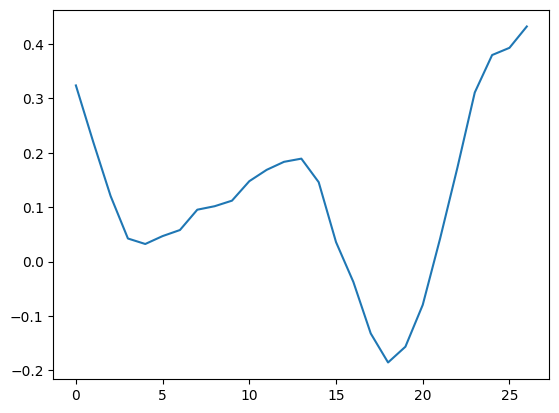

In [34]:
ri_raw['ROE'].plot()

<AxesSubplot: >

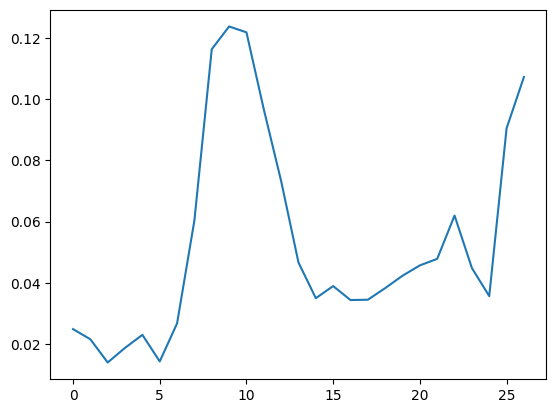

In [36]:
ri_raw["required_return_q_avg"].plot()

<AxesSubplot: >

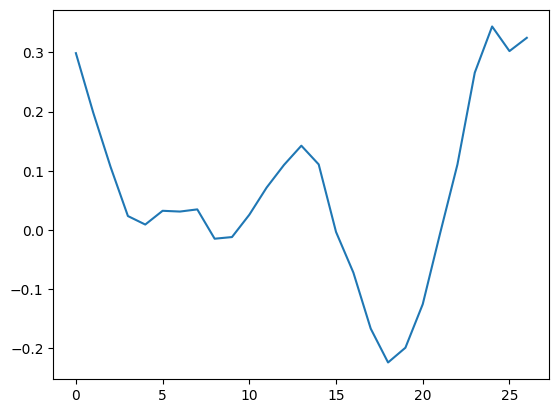

In [39]:
ri_raw['spread'] = ri_raw['ROE'] - ri_raw['required_return_q_avg']
ri_raw['spread'].plot()

In [60]:
df = fetch_table_data(db_info, 'korea_required_return_result')


# 1) required_return 만 필터링
df_req = df[df["indicator"] == "required_return"].copy()

# 2) date 컬럼을 datetime 으로 변환 (중요)
df_req["date"] = pd.to_datetime(df_req["date"])

# 3) pivot table 생성
pivot = df_req.pivot_table(
    index="date",
    columns="ticker",
    values="value"
)

# 4) 날짜 기준 정렬
pivot = pivot.sort_index()

pivot

✅ 'korea_required_return_result' 테이블에서 306075건의 데이터를 가져왔습니다.


ticker,000660,005380,005930,005935,012450,034020,105560
date,,,,,,,
2019-02-21,2.690998,2.446669,2.690337,2.679593,2.439603,2.685403,2.485671
2019-02-22,3.004672,2.647156,3.003738,2.987991,2.636761,2.995779,2.704186
2019-02-25,2.932863,2.601060,2.928889,2.913105,2.591678,2.921454,2.650238
2019-02-26,2.776875,2.497769,2.774585,2.760872,2.491060,2.767875,2.540731
2019-02-27,2.887885,2.564492,2.886091,2.870139,2.555403,2.878522,2.612480
...,...,...,...,...,...,...,...
2025-11-11,15.297614,11.137988,11.920307,10.700831,9.796471,13.405339,10.225306
2025-11-12,15.924759,11.594216,12.396258,11.121208,10.181745,13.954676,10.641756
2025-11-13,16.916817,12.254367,13.103835,11.735570,10.697576,14.778740,11.207413


In [62]:
len(df['ticker'].unique().tolist())

7

In [64]:
df['ticker'].unique().tolist()

['000660', '005380', '005930', '005935', '012450', '034020', '105560']